## Experiment: Clustering Techniques - K-Means

### Concept: Simple K-Means Implementation

This basic example demonstrates how the K-Means algorithm works by grouping a small, artificially generated dataset into distinct clusters. We'll visualize the data points and their assigned clusters along with the cluster centroids.

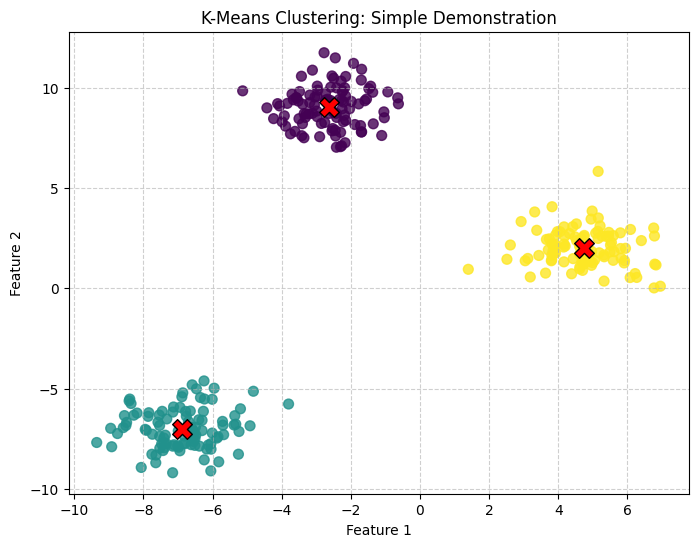

In [1]:
# Import necessary libraries
import numpy as np # NumPy is used for numerical operations, especially for creating our sample data.
import matplotlib.pyplot as plt # Matplotlib is used for plotting and visualizing the data.
from sklearn.cluster import KMeans # KMeans is the clustering algorithm we will use from scikit-learn.
from sklearn.datasets import make_blobs # make_blobs helps us create synthetic datasets with clusters.

# 1. Generate synthetic data
# We'll create a dataset with 300 samples, 2 features (for easy 2D plotting),
# and 3 distinct centers (which K-Means will try to find).
# random_state ensures that the data generation is reproducible.
X, y = make_blobs(n_samples=300, centers=3, n_features=2, random_state=42)

# 2. Initialize and apply K-Means
# We instantiate the KMeans model, telling it to look for 3 clusters (n_clusters=3).
# random_state is set for reproducibility of the clustering results.
# n_init='auto' ensures the algorithm runs multiple times with different centroid seeds
# and picks the best result (a good practice for KMeans).
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')

# Fit the KMeans model to our data 'X'. This is where the algorithm learns the clusters.
kmeans.fit(X)

# Get the cluster labels for each data point.
# `labels_` attribute stores the cluster assignment (0, 1, or 2) for each sample.
labels = kmeans.labels_

# Get the coordinates of the cluster centers (centroids).
# `cluster_centers_` attribute stores the coordinates of the center of each cluster.
centers = kmeans.cluster_centers_

# 3. Visualize the results
# Create a figure and an axes for our plot.
plt.figure(figsize=(8, 6))

# Plot each data point, colored according to its assigned cluster label.
# 'c=labels' uses the cluster labels for coloring.
# 'cmap=\'viridis\'' sets the color map for distinct colors.
# 'marker=\'o\'' sets the shape of the data points to circles.
# 's=50' sets the size of the data points.
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', marker='o', s=50, alpha=0.8)

# Plot the cluster centroids.
# 'marker=\'X\'' sets the shape of the centroids to 'X'.
# 's=200' makes them larger to stand out.
# 'color=\'red\'' makes them red.
# 'alpha=1.0' ensures they are fully opaque.
# 'edgecolor=\'black\'' adds a black border to the centroids for better visibility.
plt.scatter(centers[:, 0], centers[:, 1], marker='X', s=200, color='red', alpha=1.0, edgecolor='black')

# Add titles and labels for clarity.
plt.title('K-Means Clustering: Simple Demonstration')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show() # Display the plot.

### Application: Customer Segmentation using K-Means

This example demonstrates a more practical application of K-Means: customer segmentation. We'll use a synthetic dataset representing customer purchasing behavior, apply K-Means to identify distinct customer groups, and then visualize these segments. This helps businesses understand their customer base better and tailor marketing strategies.

Original Customer Data Head:


,CustomerID,AnnualIncome,SpendingScore,Age
0,1,136958,85,65
1,2,146932,82,42
2,3,118694,70,57
3,4,134879,91,62
4,5,125268,89,18


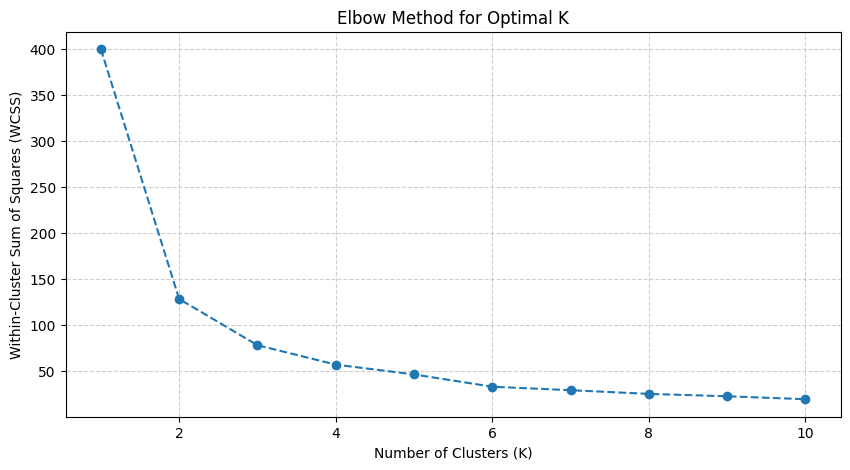


Based on the elbow plot, let's choose K=4 as the optimal number of clusters (this can be subjective).

Customer Data with Cluster Assignments Head:


,CustomerID,AnnualIncome,SpendingScore,Age,Cluster
0,1,136958,85,65,0
1,2,146932,82,42,0
2,3,118694,70,57,0
3,4,134879,91,62,0
4,5,125268,89,18,0


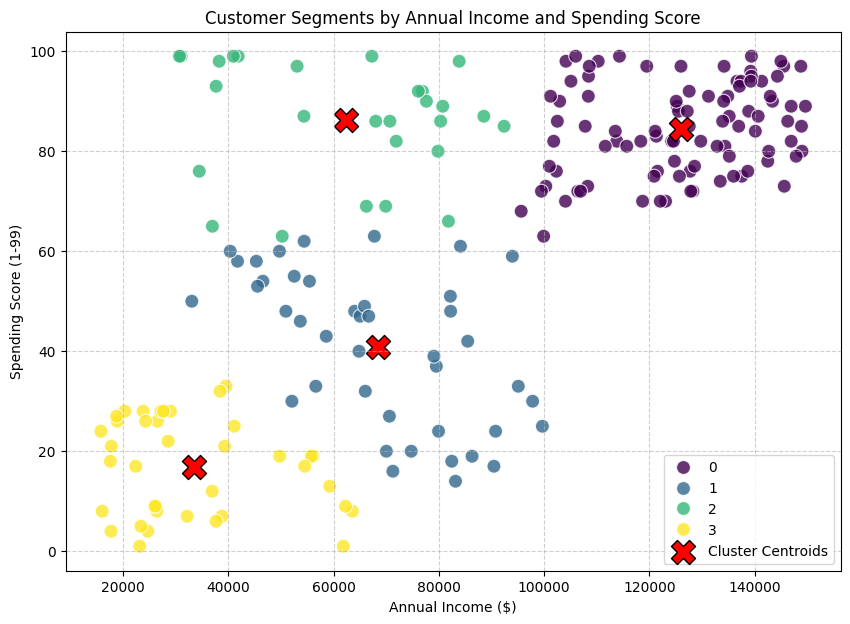


Cluster Characteristics (Mean Values):


,AnnualIncome,SpendingScore,Age
Cluster,,,
0,126086.010753,84.473118,45.924731
1,68452.380952,40.809524,42.738095
2,62272.666667,86.333333,44.481481
3,33387.921053,16.921053,41.210526



Silhouette Score: 0.50

Interpretation: The clusters represent different customer segments. For example:
  - Cluster 0 (e.g., Low Income, Low Spending)
  - Cluster 1 (e.g., High Income, High Spending)
  - And so on... 
This information can be used to target specific marketing campaigns to each segment.


In [2]:
# Import necessary libraries
import pandas as pd # Pandas is used for data manipulation and analysis.
import matplotlib.pyplot as plt # Matplotlib for plotting.
import seaborn as sns # Seaborn for enhanced visualizations.
from sklearn.cluster import KMeans # KMeans algorithm from scikit-learn.
from sklearn.preprocessing import StandardScaler # StandardScaler for feature scaling.
from sklearn.metrics import silhouette_score # To evaluate clustering performance.

# 1. Generate synthetic customer data
# We create a DataFrame to simulate customer data with various purchasing behaviors.
# 'CustomerID' is a unique identifier.
# 'AnnualIncome' represents the customer's annual income.
# 'SpendingScore' is a score (1-99) assigned by the mall based on customer behavior.
# 'Age' is the customer's age.
np.random.seed(42) # For reproducibility
customer_data = pd.DataFrame({
    'CustomerID': range(1, 201),
    'AnnualIncome': np.random.randint(15000, 150000, 200),
    'SpendingScore': np.random.randint(1, 100, 200),
    'Age': np.random.randint(18, 70, 200)
})

# Introduce some structure to make clusters more apparent for demonstration
# For example, higher income might lead to higher spending, or vice-versa for certain segments
customer_data.loc[customer_data['AnnualIncome'] > 100000, 'SpendingScore'] = np.random.randint(70, 100, sum(customer_data['AnnualIncome'] > 100000))
customer_data.loc[customer_data['AnnualIncome'] < 30000, 'SpendingScore'] = np.random.randint(1, 30, sum(customer_data['AnnualIncome'] < 30000))

print("Original Customer Data Head:")
display(customer_data.head()) # Display the first few rows of the generated data.

# 2. Select features for clustering and preprocess them
# We choose 'AnnualIncome' and 'SpendingScore' as features for segmentation.
# It's important to scale features for K-Means because it uses distance metrics.
X_segmentation = customer_data[['AnnualIncome', 'SpendingScore']]

# Initialize StandardScaler, which transforms data to have a mean of 0 and standard deviation of 1.
scaler = StandardScaler()
# Fit the scaler to our data and then transform it.
# This prevents features with larger values from dominating the distance calculations.
X_scaled = scaler.fit_transform(X_segmentation)

# 3. Determine the optimal number of clusters (Elbow Method)
# The Elbow Method helps in finding a good number of clusters.
# We calculate the Within-Cluster Sum of Squares (WCSS) for different numbers of clusters.
wcss = [] # List to store WCSS values
# We'll try clustering with 1 to 10 clusters.
for i in range(1, 11):
    kmeans_elbow = KMeans(n_clusters=i, random_state=42, n_init='auto') # Initialize KMeans for each 'i'
    kmeans_elbow.fit(X_scaled) # Fit the model to scaled data
    wcss.append(kmeans_elbow.inertia_) # 'inertia_' is the WCSS attribute

# Plot the Elbow Method results
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--') # Plot WCSS vs. number of clusters
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("\nBased on the elbow plot, let's choose K=4 as the optimal number of clusters (this can be subjective).")

# 4. Apply K-Means with the chosen number of clusters
# Instantiate KMeans with the optimal number of clusters (e.g., 4, based on the elbow plot).
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init='auto')

# Fit the model and get the cluster labels for each customer.
cluster_labels = kmeans_final.fit_predict(X_scaled)

# Add the cluster labels back to our original customer DataFrame.
customer_data['Cluster'] = cluster_labels

# 5. Analyze and Visualize the Clusters
print("\nCustomer Data with Cluster Assignments Head:")
display(customer_data.head()) # Display data with new 'Cluster' column.

# Visualize the clusters
plt.figure(figsize=(10, 7))
# Use seaborn's scatterplot for better aesthetics and automatic legend.
# 'x' and 'y' are the original, unscaled features for better interpretability.
# 'hue' is set to 'Cluster' to color points by their assigned cluster.
# 'palette' specifies the color scheme.
sns.scatterplot(x='AnnualIncome', y='SpendingScore', hue='Cluster', data=customer_data,
                palette='viridis', s=100, alpha=0.8, edgecolor='w')

# Plot centroids on the unscaled data for interpretability.
# We need to inverse transform the centroids to put them back into the original scale.
centers_unscaled = scaler.inverse_transform(kmeans_final.cluster_centers_)
plt.scatter(centers_unscaled[:, 0], centers_unscaled[:, 1], marker='X', s=300,
            color='red', edgecolor='black', label='Cluster Centroids')

plt.title('Customer Segments by Annual Income and Spending Score')
plt.xlabel('Annual Income ($)')
plt.ylabel('Spending Score (1-99)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Further analysis: Look at the characteristics of each cluster
print("\nCluster Characteristics (Mean Values):")
display(customer_data.groupby('Cluster')[['AnnualIncome', 'SpendingScore', 'Age']].mean())

# Evaluate clustering using Silhouette Score
# The Silhouette Score measures how similar an object is to its own cluster (cohesion)
# compared to other clusters (separation). Higher values indicate better clustering.
silhouette_avg = silhouette_score(X_scaled, cluster_labels)
print(f"\nSilhouette Score: {silhouette_avg:.2f}")

print("\nInterpretation: The clusters represent different customer segments. For example:")
print("  - Cluster 0 (e.g., Low Income, Low Spending)")
print("  - Cluster 1 (e.g., High Income, High Spending)")
print("  - And so on... \nThis information can be used to target specific marketing campaigns to each segment.")